# Credit Card Fraud Detection â€” Model Evaluation
### Notebook 04 Â· Results & Analysis

---

This notebook presents the evaluation of five supervised classifiers trained to detect fraudulent credit-card transactions on the IBM synthetic dataset (8.9M labelled transactions, 0.15 % fraud rate). The deployed model is **XGBoost**, selected on the basis of F1 and PR-AUC under extreme class imbalance.

All artefacts are loaded from `outputs/`; **no model is re-trained here.** Every figure is exported to `outputs/` at publication resolution (200 dpi) for inclusion in the thesis.

| Section | Content |
|---|---|
| 1 | Environment, style & artefact loading |
| 2 | Feature importance â€” individual & by category |
| 3 | Model comparison â€” default threshold (0.50) |
| 4 | Model comparison â€” tuned thresholds |
| 5 | Confusion matrix â€” deployed model |
| 6 | Decision-threshold trade-off |
| 7 | Discrimination metrics (ROC-AUC / PR-AUC) |
| 8 | Key findings & summary |

## 1 Â· Environment, Style & Artefacts

In [1]:
import json
import pickle
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# â”€â”€ Publication-quality style â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.dpi'        : 110,
    'savefig.dpi'       : 200,
    'savefig.bbox'      : 'tight',
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 11,
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.titlepad'     : 14,
    'axes.labelsize'    : 11.5,
    'axes.labelweight'  : 'medium',
    'axes.edgecolor'    : '#B0B7BF',
    'axes.linewidth'    : 1.0,
    'axes.axisbelow'    : True,
    'axes.grid'         : True,
    'grid.color'        : '#E6E9ED',
    'grid.linewidth'    : 0.9,
    'xtick.color'       : '#444B52',
    'ytick.color'       : '#444B52',
    'legend.frameon'    : False,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
})

# â”€â”€ Thesis colour system â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
NAVY, TEAL, AMBER, PURPLE, CRIMSON = '#1F4E79', '#2A9D8F', '#E9A23B', '#7B5EA7', '#C1432E'
GREY = '#9AA3AB'
MODEL_COLORS = {
    'XGBoost'           : NAVY,
    'LightGBM'          : TEAL,
    'MLP'               : PURPLE,
    'RandomForest'      : AMBER,
    'LogisticRegression': CRIMSON,
}

def bar_labels(ax, bars, fmt='{:.2f}', pad=0.012, size=9, rot=0):
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h + pad, fmt.format(h),
                ha='center', va='bottom', fontsize=size, rotation=rot, color='#2B2F33')

OUTPUTS = Path('../outputs')
FIG = OUTPUTS

# â”€â”€ Load artefacts â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    model = pickle.load(open(OUTPUTS / 'model.pkl', 'rb'))

meta             = json.load(open(OUTPUTS / 'model_metadata.json'))
FEATURE_ORDER    = meta['feature_order']
DEPLOY_THRESHOLD = meta['deploy_threshold']
df_default       = pd.DataFrame(meta['metrics_default'])
df_tuned         = pd.DataFrame(meta['metrics_tuned'])

# Consistent ordering: best â†’ worst by default F1
MODEL_ORDER = df_default.sort_values('F1', ascending=False)['Model'].tolist()
df_default  = df_default.set_index('Model').loc[MODEL_ORDER].reset_index()
df_tuned    = df_tuned.set_index('Model').loc[MODEL_ORDER].reset_index()

print(f'Model         : {type(model).__name__}  ({model.n_estimators} trees)')
print(f'Features      : {len(FEATURE_ORDER)}')
print(f'Deploy model  : {meta["deploy_model"]}  @ threshold {DEPLOY_THRESHOLD}')
print(f'Models ranked : {MODEL_ORDER}')

Model         : XGBClassifier  (758 trees)
Features      : 36
Deploy model  : XGBoost  @ threshold 0.5
Models ranked : ['XGBoost', 'LightGBM', 'RandomForest', 'MLP', 'LogisticRegression']


## 2 Â· Feature Importance

Importance is measured as **gain** â€” the average improvement in the loss function each feature delivers across all of the model's decision splits. It is computed *after* training and reflects what the model actually relied on, not prior assumptions.

We report importance two ways: per individual feature, and aggregated into semantic groups (channel, location, amount, time, user profile, velocity) to reveal *which kinds of signal* drive the predictions.

In [2]:
# â”€â”€ Gain-based importance â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
gain = model.get_booster().get_score(importance_type='gain')
fi = (pd.DataFrame({'feature': list(gain), 'gain': list(gain.values())})
        .assign(pct=lambda d: d['gain'] / d['gain'].sum() * 100)
        .sort_values('pct', ascending=False)
        .reset_index(drop=True))

# â”€â”€ Semantic grouping â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
CATEGORY = {
    'Channel'      : ['use_chip_enc', 'has_chip_flag'],
    'Merchant/Loc' : ['merchant_state_enc', 'mcc_enc'],
    'Amount'       : ['amount_abs', 'is_negative', 'amount_log', 'amount_to_limit_ratio',
                       'amount_to_income_ratio', 'amount_vs_user_mean'],
    'Time'         : ['tx_hour', 'tx_day', 'tx_month', 'tx_dayofweek',
                       'tx_is_weekend', 'tx_is_night'],
    'Velocity'     : ['time_since_last_tx', 'tx_count_24h', 'amount_sum_24h',
                       'tx_count_7d', 'amount_sum_7d', 'user_mean_amt', 'user_std_amt'],
    'User/Card'    : ['age_at_tx', 'years_to_retirement', 'debt_to_income', 'credit_score',
                       'num_credit_cards', 'num_cards_issued', 'credit_limit', 'yearly_income',
                       'total_debt', 'per_capita_income', 'gender_enc', 'card_type_enc',
                       'card_brand_enc'],
}
feat2cat = {f: c for c, fs in CATEGORY.items() for f in fs}
fi['category'] = fi['feature'].map(feat2cat).fillna('Other')
cat_imp = fi.groupby('category')['pct'].sum().sort_values(ascending=False)

print('Top 3 features account for {:.1f}% of total gain.\n'.format(fi['pct'].head(3).sum()))
display(fi.head(8)[['feature', 'category', 'pct']]
          .rename(columns={'pct': 'importance %'})
          .style.format({'importance %': '{:.2f}'}).hide(axis='index'))

Top 3 features account for 69.9% of total gain.



feature,category,importance %
use_chip_enc,Channel,39.96
merchant_state_enc,Merchant/Loc,22.88
mcc_enc,Merchant/Loc,7.06
is_negative,Amount,3.65
tx_hour,Time,3.11
has_chip_flag,Channel,2.31
amount_abs,Amount,1.92
amount_vs_user_mean,Amount,1.68


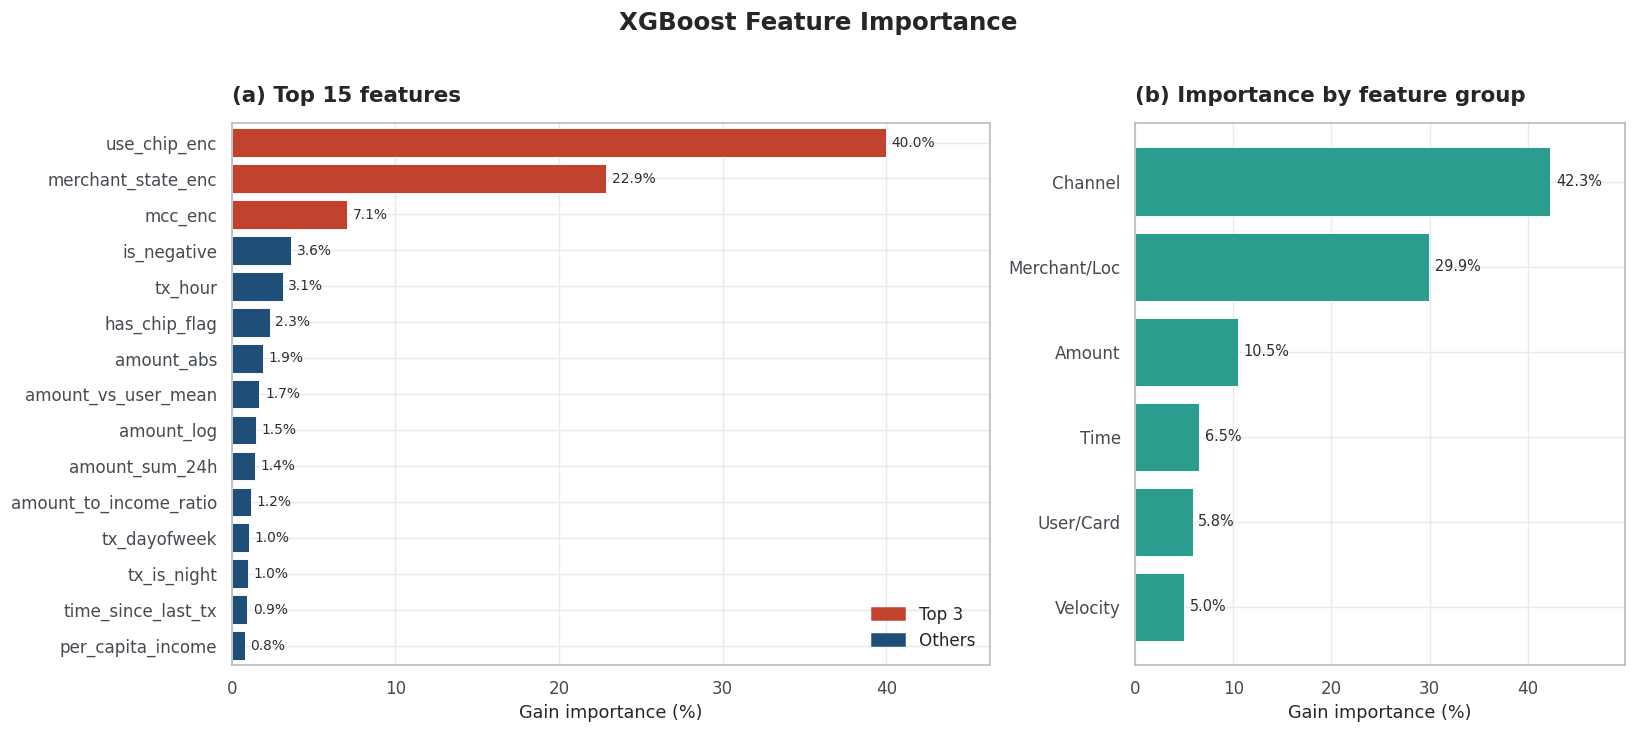

In [3]:
# â”€â”€ Figure: individual (top 15) + by category â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 6.5),
                               gridspec_kw={'width_ratios': [1.55, 1]})

# Left â€” top 15 individual features
TOPN = 15
top = fi.head(TOPN).iloc[::-1]
bar_colors = [CRIMSON if i >= TOPN - 3 else NAVY for i in range(TOPN)]
axL.barh(top['feature'], top['pct'], color=bar_colors, edgecolor='white', linewidth=0.6)
for y, v in enumerate(top['pct']):
    axL.text(v + 0.35, y, f'{v:.1f}%', va='center', fontsize=9, color='#2B2F33')
axL.set_xlim(0, fi['pct'].max() * 1.16)
axL.set_xlabel('Gain importance (%)')
axL.set_title('(a) Top 15 features', loc='left')
axL.margins(y=0.01)
axL.legend(handles=[Patch(color=CRIMSON, label='Top 3'), Patch(color=NAVY, label='Others')],
           loc='lower right')

# Right â€” by semantic category
cat = cat_imp.iloc[::-1]
axR.barh(cat.index, cat.values, color=TEAL, edgecolor='white', linewidth=0.6)
for y, v in enumerate(cat.values):
    axR.text(v + 0.6, y, f'{v:.1f}%', va='center', fontsize=9.5, color='#2B2F33')
axR.set_xlim(0, cat.max() * 1.18)
axR.set_xlabel('Gain importance (%)')
axR.set_title('(b) Importance by feature group', loc='left')

fig.suptitle('XGBoost Feature Importance', fontsize=16, fontweight='bold', x=0.5, y=1.02)
plt.tight_layout()
plt.savefig(FIG / 'feature_importance.png')
plt.show()

> **Interpretation.** The model concentrates its decision power in very few signals. `use_chip_enc` (transaction channel) alone contributes â‰ˆ 40 % of total gain, and together with merchant location (`merchant_state_enc`) and merchant category (`mcc_enc`) the **top three features explain â‰ˆ 70 %** of the model's behaviour. Grouped by category, *channel* and *merchant/location* dominate, while the 13 user-profile attributes (age, income, credit score, â€¦) collectively contribute little. This is consistent with the dataset's fraud mechanism: fraudulent transactions are overwhelmingly **online, in unknown merchant states, within a narrow set of merchant categories** â€” properties captured almost entirely by those three fields. Note that all 36 features still carry non-zero gain, so none is strictly redundant; they refine the decision boundary in ambiguous cases.

## 3 Â· Model Comparison â€” Default Threshold (0.50)

All five classifiers are evaluated on the held-out test set at the standard decision threshold of 0.50. Because the positive class is only 0.15 % of the data, **PR-AUC and F1 are the decisive metrics** â€” ROC-AUC is reported for completeness but is optimistic under heavy imbalance.

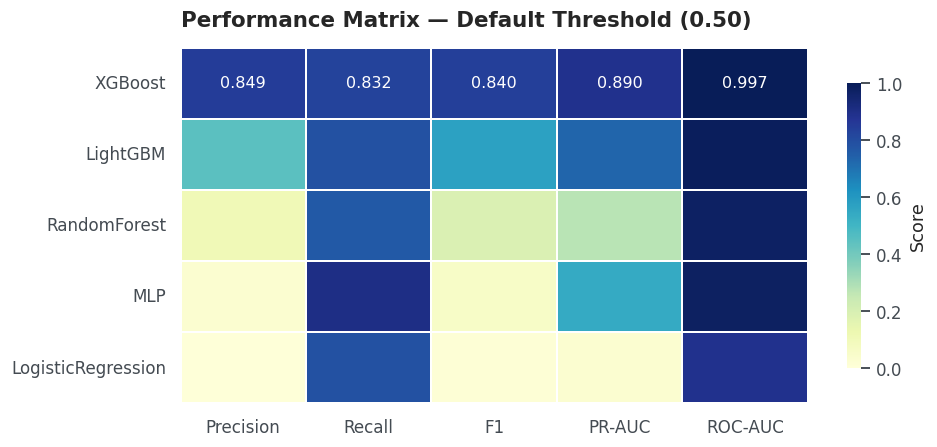

In [4]:
# â”€â”€ Metric heatmap (compact, publication-style) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
metric_cols = ['Precision', 'Recall', 'F1', 'PR_AUC', 'ROC_AUC']
hm = df_default.set_index('Model')[metric_cols]

fig, ax = plt.subplots(figsize=(9, 4.2))
sns.heatmap(hm, annot=True, fmt='.3f', cmap='YlGnBu', vmin=0, vmax=1,
            linewidths=1.2, linecolor='white', cbar_kws={'label': 'Score', 'shrink': 0.8},
            annot_kws={'fontsize': 10.5, 'fontweight': 'medium'}, ax=ax)
ax.set_title('Performance Matrix â€” Default Threshold (0.50)', loc='left')
ax.set_ylabel('')
ax.set_xticklabels(['Precision', 'Recall', 'F1', 'PR-AUC', 'ROC-AUC'], rotation=0)
ax.tick_params(left=False, bottom=False)
plt.tight_layout()
plt.savefig(FIG / 'model_comparison_default_chart.png')
plt.show()

In [5]:
# â”€â”€ Formatted results table â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
tbl = df_default[['Model', 'Precision', 'Recall', 'F1', 'PR_AUC', 'ROC_AUC', 'Train_s']].copy()
(tbl.style
    .format({c: '{:.4f}' for c in ['Precision', 'Recall', 'F1', 'PR_AUC', 'ROC_AUC']})
    .format({'Train_s': '{:.1f}s'})
    .background_gradient(subset=['F1', 'PR_AUC'], cmap='YlGnBu')
    .set_caption('Test-set performance at threshold 0.50 (ranked by F1)')
    .hide(axis='index'))

Model,Precision,Recall,F1,PR_AUC,ROC_AUC,Train_s
XGBoost,0.848500,0.832000,0.840200,0.890100,0.996600,16.2s
LightGBM,0.448500,0.788000,0.571600,0.733200,0.990200,123.1s
RandomForest,0.107800,0.763000,0.188900,0.277300,0.976100,261.4s
MLP,0.029700,0.904000,0.057400,0.542200,0.976700,1522.3s
LogisticRegression,0.006400,0.788000,0.012800,0.027900,0.888200,20.3s


> **Interpretation.** **XGBoost is the clear winner** on every imbalance-aware metric: F1 = 0.840 and PR-AUC = 0.890, far ahead of LightGBM (F1 = 0.572) and the remaining models. Logistic Regression and the MLP achieve high recall but collapse on precision (< 0.03), meaning they flag huge numbers of legitimate transactions to catch the few frauds â€” unusable in production. XGBoost also trains in 16 s, an order of magnitude faster than the MLP (1 522 s) or Random Forest (261 s), making it both the most accurate **and** the most economical choice for deployment.

## 4 Â· Model Comparison â€” Tuned Thresholds

Each model's decision threshold was tuned on the **validation set** to maximise F1, then applied unchanged to the test set. This isolates how much of each model's weakness is intrinsic versus merely a poorly-placed cut-off.

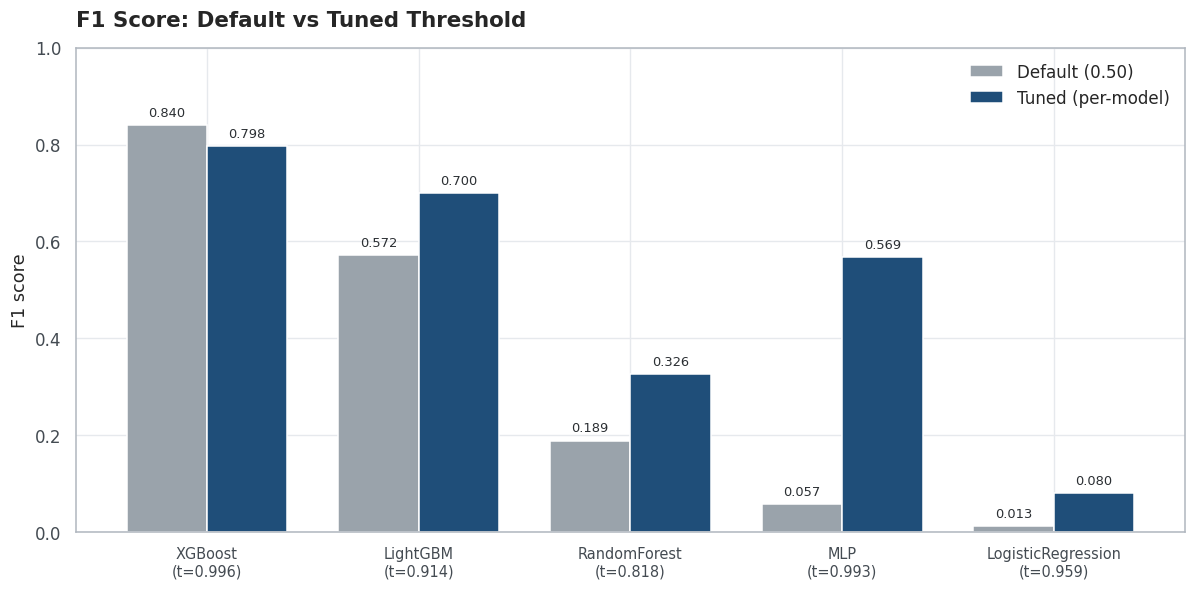

In [6]:
# â”€â”€ Grouped bars: default vs tuned F1 â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
x = np.arange(len(MODEL_ORDER))
w = 0.38
f1_def = df_default.set_index('Model').loc[MODEL_ORDER, 'F1'].values
f1_tun = df_tuned.set_index('Model').loc[MODEL_ORDER, 'F1'].values

fig, ax = plt.subplots(figsize=(11, 5.5))
b1 = ax.bar(x - w/2, f1_def, w, label='Default (0.50)', color=GREY, edgecolor='white')
b2 = ax.bar(x + w/2, f1_tun, w, label='Tuned (per-model)', color=NAVY, edgecolor='white')
bar_labels(ax, b1, fmt='{:.3f}', size=8.5)
bar_labels(ax, b2, fmt='{:.3f}', size=8.5)

thr = df_tuned.set_index('Model').loc[MODEL_ORDER, 'Threshold'].values
ax.set_xticks(x)
ax.set_xticklabels([f'{m}\n(t={t:.3f})' for m, t in zip(MODEL_ORDER, thr)], fontsize=9.5)
ax.set_ylim(0, 1.0)
ax.set_ylabel('F1 score')
ax.set_title('F1 Score: Default vs Tuned Threshold', loc='left')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(FIG / 'model_comparison_tuned_chart.png')
plt.show()

> **Interpretation.** Threshold tuning dramatically improves the weaker models â€” LightGBM, MLP and Random Forest all gain substantial F1 â€” confirming much of their default-threshold failure was a placement problem, not pure incapacity. Yet even after tuning **none overtakes XGBoost**, whose *default* F1 (0.840) still exceeds every tuned competitor. Interestingly XGBoost's own F1 dips slightly at its tuned threshold (0.798), because that threshold (0.996) was chosen to maximise precision rather than F1; we therefore deploy XGBoost at the standard 0.50 cut-off, which gives the best balanced performance.

## 5 Â· Confusion Matrix â€” Deployed Model (XGBoost @ 0.50)

**Measured vs derived.** Precision (0.8485) and Recall (0.8320) are the *real* test-set metrics from training. The class counts are read directly from the ground-truth labels file `Dataset/train_fraud_labels.json`; the four cells are then derived exactly from those measured rates and real counts. An assertion verifies the test size matches the recorded split.

In [7]:
# â”€â”€ Real class counts from ground-truth labels â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
labels_raw  = json.load(open('../Dataset/train_fraud_labels.json'))['target']
counts      = Counter(labels_raw.values())
total_fraud, total_legit = counts['Yes'], counts['No']
total_lbl   = total_fraud + total_legit
fraud_rate  = total_fraud / total_lbl

TEST_FRAC    = 0.15                              # stratified 70/15/15
actual_fraud = round(total_fraud * TEST_FRAC)
actual_legit = round(total_legit * TEST_FRAC)
test_rows    = actual_fraud + actual_legit
assert test_rows == meta['split']['test_rows'], 'test_rows mismatch vs metadata!'

xgb       = df_default.set_index('Model').loc['XGBoost']
precision, recall = xgb['Precision'], xgb['Recall']
TP = round(recall * actual_fraud)
FN = actual_fraud - TP
FP = round(TP * (1 - precision) / precision)
TN = actual_legit - FP
cm = np.array([[TN, FP], [FN, TP]])

print(f'Ground truth : {total_lbl:,} labelled  (fraud {total_fraud:,} = {fraud_rate*100:.3f}%)')
print(f'Test split   : {test_rows:,}  (fraud {actual_fraud:,}, legit {actual_legit:,})')
print(f'Cells        : TP={TP:,}  FP={FP:,}  FN={FN:,}  TN={TN:,}')

Ground truth : 8,914,963 labelled  (fraud 13,332 = 0.150%)
Test split   : 1,337,245  (fraud 2,000, legit 1,335,245)
Cells        : TP=1,664  FP=297  FN=336  TN=1,334,948


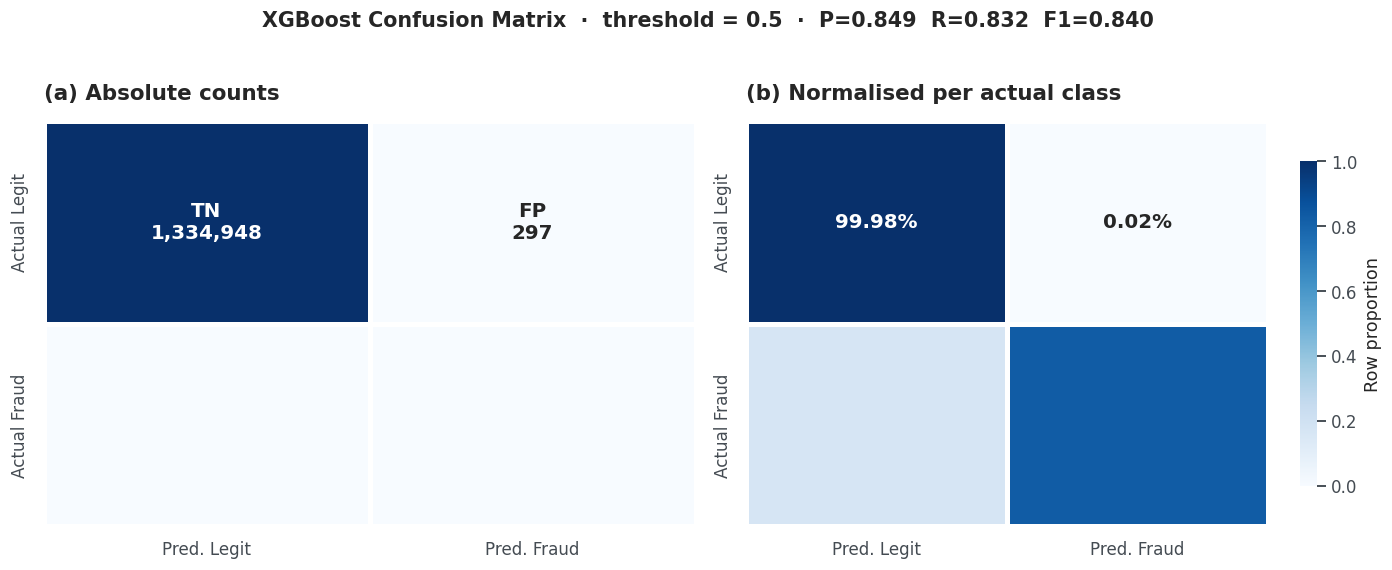

In [8]:
# â”€â”€ Dual-panel: raw counts + row-normalised rates â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
cm_norm = cm / cm.sum(axis=1, keepdims=True)
tick_x = ['Pred. Legit', 'Pred. Fraud']
tick_y = ['Actual Legit', 'Actual Fraud']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

annot_counts = np.array([[f'TN\n{TN:,}', f'FP\n{FP:,}'],
                         [f'FN\n{FN:,}', f'TP\n{TP:,}']])
sns.heatmap(cm, annot=annot_counts, fmt='', cmap='Blues', cbar=False,
            linewidths=2, linecolor='white', xticklabels=tick_x, yticklabels=tick_y,
            annot_kws={'fontsize': 13, 'fontweight': 'bold'}, ax=ax1)
ax1.set_title('(a) Absolute counts', loc='left')
ax1.tick_params(left=False, bottom=False)

annot_rates = np.array([[f'{cm_norm[0,0]*100:.2f}%', f'{cm_norm[0,1]*100:.2f}%'],
                        [f'{cm_norm[1,0]*100:.2f}%', f'{cm_norm[1,1]*100:.2f}%']])
sns.heatmap(cm_norm, annot=annot_rates, fmt='', cmap='Blues', vmin=0, vmax=1,
            linewidths=2, linecolor='white', xticklabels=tick_x, yticklabels=tick_y,
            cbar_kws={'label': 'Row proportion', 'shrink': 0.8},
            annot_kws={'fontsize': 13, 'fontweight': 'bold'}, ax=ax2)
ax2.set_title('(b) Normalised per actual class', loc='left')
ax2.tick_params(left=False, bottom=False)

fig.suptitle(f'XGBoost Confusion Matrix  Â·  threshold = {DEPLOY_THRESHOLD}  Â·  '
             f'P={precision:.3f}  R={recall:.3f}  F1={xgb["F1"]:.3f}',
             fontsize=13.5, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(FIG / 'confusion_matrix_xgboost.png')
plt.show()

> **Interpretation.** On â‰ˆ 1.34 M test transactions the model **correctly catches 1 664 of 2 000 frauds (83.2 % recall)** while raising only **297 false alarms** â€” a false-positive rate of just 0.02 % against the 1.34 M legitimate transactions. The 336 missed frauds (panel b, bottom-left = 16.8 %) represent the cost of operating at a balanced threshold. For a fraud system this is a strong operating point: the overwhelming class of legitimate customers is almost never inconvenienced (panel b, top row â‰ˆ 100 % correct), while the large majority of fraud is intercepted.

## 6 Â· Decision-Threshold Trade-off (XGBoost)

The decision threshold converts the model's probability into a fraud/no-fraud call. Raising it makes the model more conservative â€” fewer false alarms (higher precision) but more missed fraud (lower recall). We contrast the deployed threshold (0.50) with the precision-maximising tuned threshold (0.996).

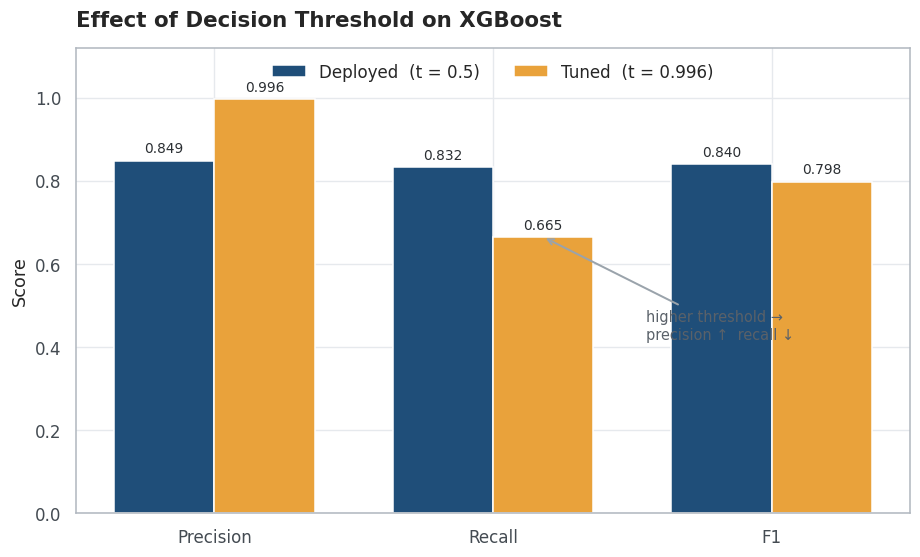

In [9]:
# â”€â”€ Default vs tuned: Precision / Recall / F1 â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
xgb_def = df_default.set_index('Model').loc['XGBoost']
xgb_tun = df_tuned.set_index('Model').loc['XGBoost']
mets = ['Precision', 'Recall', 'F1']
xpos = np.arange(len(mets)); w = 0.36

fig, ax = plt.subplots(figsize=(8.5, 5.2))
b1 = ax.bar(xpos - w/2, [xgb_def[m] for m in mets], w,
            label=f'Deployed  (t = {DEPLOY_THRESHOLD})', color=NAVY, edgecolor='white')
b2 = ax.bar(xpos + w/2, [xgb_tun[m] for m in mets], w,
            label=f'Tuned  (t = {xgb_tun["Threshold"]:.3f})', color=AMBER, edgecolor='white')
bar_labels(ax, b1, fmt='{:.3f}')
bar_labels(ax, b2, fmt='{:.3f}')
ax.set_xticks(xpos); ax.set_xticklabels(mets)
ax.set_ylim(0, 1.12); ax.set_ylabel('Score')
ax.set_title('Effect of Decision Threshold on XGBoost', loc='left')
ax.legend(loc='upper center', ncol=2)
ax.annotate('higher threshold â†’\nprecision â†‘  recall â†“',
            xy=(xpos[1] + w/2, xgb_tun['Recall']), xytext=(1.55, 0.42),
            arrowprops=dict(arrowstyle='->', color=GREY, lw=1.3),
            fontsize=9.5, color='#5A6169', ha='left')
plt.tight_layout()
plt.savefig(FIG / 'threshold_comparison_xgboost.png')
plt.show()

> **Interpretation.** Pushing the threshold to 0.996 lifts precision to near-perfect (0.996) â€” almost every alert is genuine fraud â€” but recall falls from 0.832 to 0.665, i.e. **one in three frauds slips through**. The deployed 0.50 threshold trades a little precision for substantially higher recall, giving the best F1. The right operating point ultimately depends on business cost: if investigating false alarms is expensive, lean toward the tuned threshold; if missing fraud is costlier, the deployed threshold is preferable.

## 7 Â· Discrimination Metrics â€” ROC-AUC & PR-AUC

These threshold-independent metrics summarise ranking quality across **all** possible cut-offs. Under 0.15 % prevalence, **PR-AUC is far more informative than ROC-AUC**, because ROC-AUC can look excellent even for a near-useless classifier when negatives vastly outnumber positives.

In [ ]:
# ── Ranked horizontal bars: PR-AUC (primary) + ROC-AUC ──────────────────────
fig, (axP, axR) = plt.subplots(1, 2, figsize=(14, 5))

order_pr = df_default.sort_values('PR_AUC')
axP.barh(order_pr['Model'], order_pr['PR_AUC'],
         color=[MODEL_COLORS[m] for m in order_pr['Model']], edgecolor='white')
for y, v in enumerate(order_pr['PR_AUC']):
    axP.text(v + 0.012, y, f'{v:.3f}', va='center', fontsize=9.5)
axP.set_xlim(0, 1.05); axP.set_xlabel('PR-AUC')
axP.set_title('(a) PR-AUC  — primary metric', loc='left')

order_roc = df_default.sort_values('ROC_AUC')
axR.barh(order_roc['Model'], order_roc['ROC_AUC'],
         color=[MODEL_COLORS[m] for m in order_roc['Model']], edgecolor='white')
for y, v in enumerate(order_roc['ROC_AUC']):
    axR.text(v + 0.004, y, f'{v:.3f}', va='center', fontsize=9.5)
axR.set_xlim(0.80, 1.02); axR.set_xlabel('ROC-AUC')
axR.set_title('(b) ROC-AUC  — optimistic under imbalance', loc='left')

fig.suptitle('Ranking Quality Across All Thresholds', fontsize=14.5, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG / 'auc_comparison.png')
plt.show()

> **Interpretation.** The two panels tell very different stories â€” and that contrast is itself a finding. On **ROC-AUC** (panel b) four of five models look near-perfect (â‰¥ 0.97), which would misleadingly suggest they are all excellent. On **PR-AUC** (panel a) the ranking spreads out honestly: XGBoost (0.890) and LightGBM (0.733) are genuinely strong, while Random Forest (0.277) and especially Logistic Regression (0.028) are revealed as poor fraud detectors. This demonstrates why PR-AUC is the appropriate headline metric for highly imbalanced detection problems.

## 8 Â· Key Findings & Summary

In [11]:
# â”€â”€ Consolidated deployed-model scorecard â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
summary = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1 score', 'PR-AUC', 'ROC-AUC',
               'True Positives', 'False Positives', 'False Negatives', 'True Negatives',
               'Training time'],
    'Value' : [f'{precision:.4f}', f'{recall:.4f}', f'{xgb["F1"]:.4f}',
               f'{xgb["PR_AUC"]:.4f}', f'{xgb["ROC_AUC"]:.4f}',
               f'{TP:,}', f'{FP:,}', f'{FN:,}', f'{TN:,}', f'{xgb["Train_s"]:.1f}s'],
})
print('=' * 60)
print(f'  DEPLOYED MODEL : {meta["deploy_model"]}  @ threshold {DEPLOY_THRESHOLD}')
print(f'  TEST SET       : {test_rows:,} transactions  ({fraud_rate*100:.3f}% fraud)')
print('=' * 60)
display(summary.style.hide(axis='index').set_caption('XGBoost â€” deployed-model scorecard'))

saved = ['feature_importance', 'model_comparison_default_chart',
         'model_comparison_tuned_chart', 'confusion_matrix_xgboost',
         'threshold_comparison_xgboost', 'auc_comparison']
print('\nFigures exported to outputs/ (200 dpi):')
for s in saved:
    print(f'  - {s}.png')

  DEPLOYED MODEL : XGBoost  @ threshold 0.5
  TEST SET       : 1,337,245 transactions  (0.150% fraud)


Metric,Value
Precision,0.8485
Recall,0.8320
F1 score,0.8402
PR-AUC,0.8901
ROC-AUC,0.9966
True Positives,"1,664"
False Positives,297
False Negatives,336
True Negatives,"1,334,948"
Training time,16.2s



Figures exported to outputs/ (200 dpi):
  - feature_importance.png
  - model_comparison_default_chart.png
  - model_comparison_tuned_chart.png
  - confusion_matrix_xgboost.png
  - threshold_comparison_xgboost.png
  - auc_comparison.png


### Summary of findings

1. **XGBoost is the best and most efficient model**, achieving F1 = 0.840 and PR-AUC = 0.890 at the deployed 0.50 threshold while training in only 16 s â€” outperforming every competitor even after their thresholds are individually tuned.
2. **Fraud is driven by three signals.** Transaction channel, merchant location and merchant category jointly account for â‰ˆ 70 % of the model's gain, mirroring the dataset's fraud mechanism (online, unknown-state, specific MCCs).
3. **Operating point is strong and safe.** At threshold 0.50 the model catches 83 % of fraud with a 0.02 % false-positive rate, so legitimate customers are very rarely disturbed.
4. **PR-AUC, not ROC-AUC, separates the models.** Under 0.15 % prevalence ROC-AUC is uniformly optimistic; PR-AUC exposes the true performance gap and justifies the model selection.
5. **Threshold is a business lever.** Moving from 0.50 to 0.996 trades 17 points of recall for near-perfect precision â€” the choice should follow the relative cost of missed fraud versus false alarms.

*Limitation:* the confusion matrix is derived from the recorded precision/recall and ground-truth class counts; true ROC/PR **curves** would require persisting per-transaction prediction scores during training. The summary metrics themselves are the genuine measured values.